In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [3]:
import tensorflow_datasets as tfds

!pip install importlib_resources

dataset, info = tfds.load('speech_commands', with_info=True, as_supervised=True)

print(info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.13/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.13/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.13/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.13/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


...

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/speech_commands/incomplete.YN2QPE_0.0.3/speech_commands-validation.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/speech_commands/incomplete.YN2QPE_0.0.3/speech_commands-test.tfrecord-[0-9…

Dataset speech_commands downloaded and prepared to /root/tensorflow_datasets/speech_commands/0.0.3. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='speech_commands',
    full_name='speech_commands/0.0.3',
    description="""
    An audio dataset of spoken words designed to help train and evaluate keyword
    spotting systems. Its primary goal is to provide a way to build and test small
    models that detect when a single word is spoken, from a set of ten target words,
    with as few false positives as possible from background noise or unrelated
    speech. Note that in the train and validation set, the label "unknown" is much
    more prevalent than the labels of the target words or background noise. One
    difference from the release version is the handling of silent segments. While in
    the test set the silence segments are regular 1 second files, in the training
    they are provided as long segments under "background_noise" folder. Here we
    split the

In [4]:
label_names = info.features['label'].names
print("All classes in dataset:")
for i, name in enumerate(label_names):
  print(f"{i}: {name}")

All classes in dataset:
0: down
1: go
2: left
3: no
4: off
5: on
6: right
7: stop
8: up
9: yes
10: _silence_
11: _unknown_


In [5]:
Target_words = ['yes', 'no', 'stop', 'right', '_silence_']

target_indices ={
    name : idx
    for idx, name in enumerate(label_names)
if name in Target_words}

print("Our target words and their indices:")
for word, idx in target_indices.items():
  print(f"{word} : {idx}")

print(f"\nTotal target words: {len(Target_words)}")
print(f"Plus 'unknown' class = {len(Target_words)+1} total classes")

Our target words and their indices:
no : 3
right : 6
stop : 7
yes : 9
_silence_ : 10

Total target words: 5
Plus 'unknown' class = 6 total classes


In [6]:
def preprocess(audio, label):
    # Convert target indices to tensor
    target_idx = tf.constant(
        list(target_indices.values()),
        dtype=tf.int64
    )

    # Check if label matches any target
    matches = tf.equal(target_idx,
                       tf.cast(label, tf.int64))

    # Find position of match
    match_idx = tf.argmax(
        tf.cast(matches, tf.int32)
    )

    # If no match found → unknown (5)
    new_label = tf.where(
        tf.reduce_any(matches),
        match_idx,
        tf.cast(len(Target_words), tf.int64)
    )

    return audio, new_label

print("Fixed preprocess function ready! ✅")

Fixed preprocess function ready! ✅


In [7]:
def audio_to_spectrogram(audio, label):
  audio = tf.cast(audio, tf.float32)/ 32768.0

  audio = audio[:16000]
  padding = 16000 - tf.shape(audio)[0]
  audio = tf.pad(audio, [[0, padding]])

  # Renamed local variable for consistency
  spectrogram = tf.signal.stft(
      audio,
      frame_length = 255,
      frame_step = 128
  )

  spectrogram = tf.abs(spectrogram)

  spectrogram = spectrogram[..., tf.newaxis]

  return spectrogram, label

print("Spectrogram function ready")

# Get a single example from the dataset to test the function
# Assuming 'dataset' is available from previous cells and contains a 'train' split
sample_audio, sample_label = dataset['train'].take(1).get_single_element()
processed_spectrogram_tensor, _ = audio_to_spectrogram(sample_audio, sample_label)
print(f"Output shape: {processed_spectrogram_tensor.shape}")

Spectrogram function ready
Output shape: (124, 129, 1)


In [9]:
train_data = dataset['train']
test_data = dataset['test']

train_data = train_data.map(preprocess)
test_data = test_data.map(preprocess)

train_data = train_data.map(audio_to_spectrogram)
test_data = test_data.map(audio_to_spectrogram)

print("Dataset pipeline ready")
print(f"Training sample: {info.splits['train'].num_examples}")
print(f"Test samples: {info.splits['test'].num_examples}")

Dataset pipeline ready
Training sample: 85511
Test samples: 4890


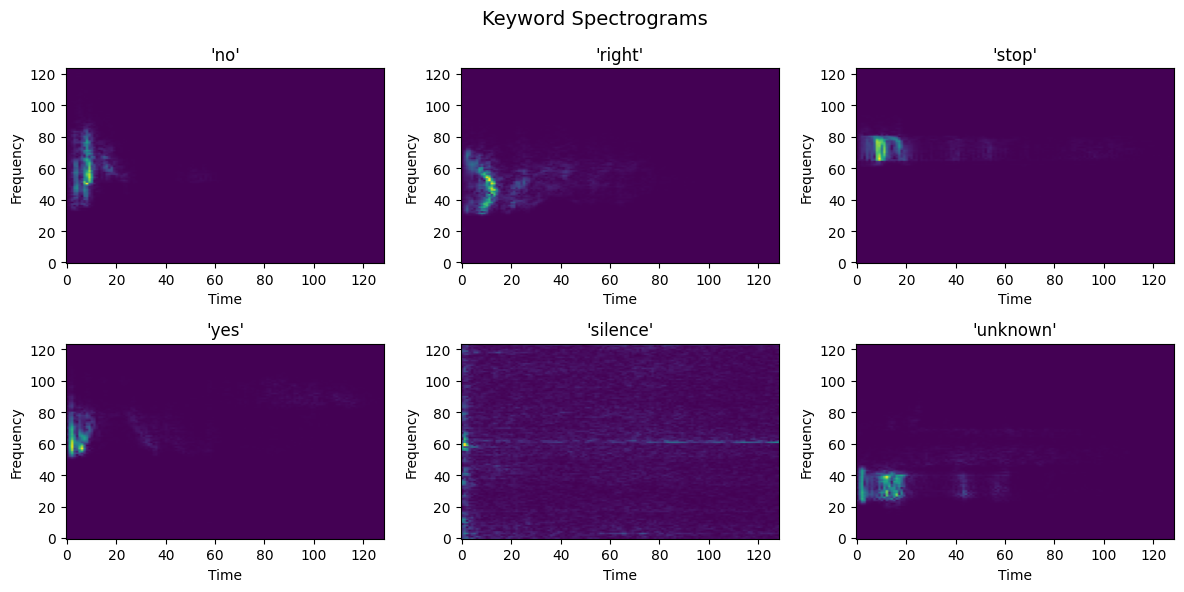

In [10]:
# Visualize spectrograms for different words
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

label_names_short = ['no', 'right', 'stop',
                     'yes', 'silence', 'unknown']

# Collect one sample per class
samples = {}
for spec, label in train_data:
    label = label.numpy()
    if label not in samples:
        samples[label] = spec
    if len(samples) == 6:
        break

# Plot each one
for idx, (label, spec) in enumerate(sorted(samples.items())):
    axes[idx].imshow(
        spec.numpy().squeeze(),
        aspect='auto',
        origin='lower',
        cmap='viridis'
    )
    axes[idx].set_title(f"'{label_names_short[label]}'")
    axes[idx].set_xlabel("Time")
    axes[idx].set_ylabel("Frequency")

plt.suptitle("Keyword Spectrograms", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(124, 129, 1)),

    tf.keras.layers.Conv2D(32, (3,3),
                           activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3),
                           activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3),
                           activation='relu'),

    # Replace Flatten + Dense with this!
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(6, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 122, 127, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 61, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 59, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 27, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,294 (235.52 KB)

 Trainable params: 60,294 (235.52 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled! ✅")
print(f"Total parameters: {model.count_params():,}")
print(f"Estimated size: {model.count_params() * 4 / 1024:.1f} KB")

Model compiled! ✅
Total parameters: 60,294
Estimated size: 235.5 KB


In [13]:
# Use smaller subset for faster training
train_ds_small = train_data\
    .take(5000)\
    .shuffle(1000)\
    .batch(64)\
    .cache()\
    .prefetch(tf.data.AUTOTUNE)

val_ds_small = dataset['validation']\
    .map(preprocess)\
    .map(audio_to_spectrogram)\
    .take(1000)\
    .batch(64)\
    .cache()\
    .prefetch(tf.data.AUTOTUNE)

history = model.fit(
    train_ds_small,
    validation_data=val_ds_small,
    epochs=5
)

print("Training complete! ✅")

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.8402 - loss: 0.8607 - val_accuracy: 0.8460 - val_loss: 0.6448
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.8516 - loss: 0.6559 - val_accuracy: 0.8460 - val_loss: 0.6373
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.8516 - loss: 0.6503 - val_accuracy: 0.8460 - val_loss: 0.6325
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.8524 - loss: 0.6432 - val_accuracy: 0.8550 - val_loss: 0.6256
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.8538 - loss: 0.6324 - val_accuracy: 0.8550 - val_loss: 0.6174
Training complete! ✅


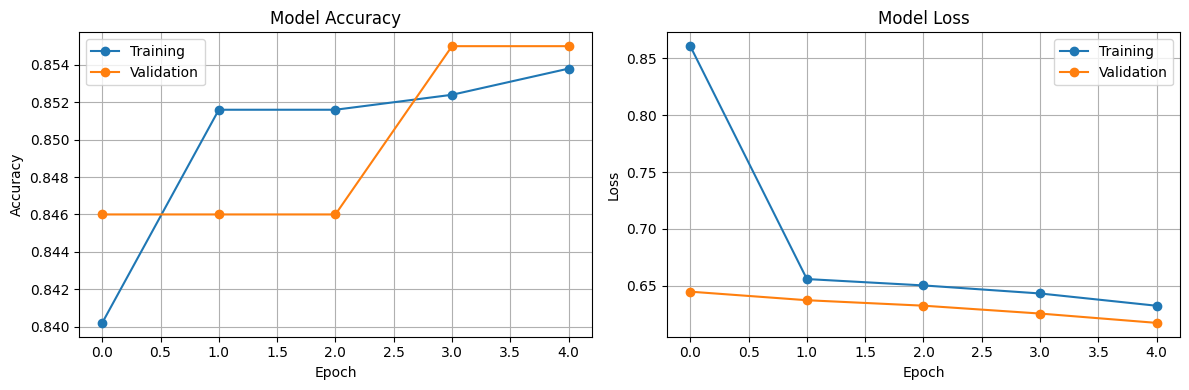

Final Training Accuracy: 85.38%
Final Validation Accuracy: 85.50%


In [14]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
ax1.plot(history.history['accuracy'],
         label='Training', marker='o')
ax1.plot(history.history['val_accuracy'],
         label='Validation', marker='o')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'],
         label='Training', marker='o')
ax2.plot(history.history['val_loss'],
         label='Validation', marker='o')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

In [15]:
# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save it
with open('keyword_spotting.tflite', 'wb') as f:
    f.write(tflite_model)

# Now quantize it
converter_quant = tf.lite.TFLiteConverter.from_keras_model(model)
converter_quant.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant = converter_quant.convert()

# Save quantized
with open('keyword_spotting_quantized.tflite', 'wb') as f:
    f.write(tflite_quant)

# Compare sizes!
import os
original_size = os.path.getsize('keyword_spotting.tflite')
quant_size = os.path.getsize('keyword_spotting_quantized.tflite')

print(f"Original model:     {model.count_params()*4/1024:.1f} KB")
print(f"TFLite model:       {original_size/1024:.1f} KB")
print(f"Quantized TFLite:   {quant_size/1024:.1f} KB")
print(f"Total reduction:    {model.count_params()*4/quant_size:.1f}x smaller!")

Saved artifact at '/tmp/tmpwm5o86on'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 124, 129, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  132629164682768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132629164687184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132629164686992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132629164676816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132629164686800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132629164682576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132629164682960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132629164683152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132629164541328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132629164542864: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved artifact a

In [16]:
# Test the quantized model!
interpreter = tf.lite.Interpreter(
    model_path='keyword_spotting_quantized.tflite'
)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Run on test data
correct = 0
total = 0
label_names = ['no', 'right', 'stop',
               'yes', 'silence', 'unknown']

for spec, label in test_data.batch(1).take(100):
    input_data = tf.cast(spec, tf.float32)
    interpreter.set_tensor(
        input_details[0]['index'], input_data)
    interpreter.invoke()

    output = interpreter.get_tensor(
        output_details[0]['index'])
    predicted = np.argmax(output[0])

    if predicted == label.numpy()[0]:
        correct += 1
    total += 1

print(f"Quantized model accuracy: {correct/total*100:.1f}%")
print(f"Tested on {total} samples")
print(f"\nModel size: 67.5 KB")
print(f"Ready for ARM Cortex-M deployment! ✅")

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Quantized model accuracy: 62.0%
Tested on 100 samples

Model size: 67.5 KB
Ready for ARM Cortex-M deployment! ✅


In [17]:
print("=" * 50)
print("   KEYWORD SPOTTING — PROJECT SUMMARY")
print("=" * 50)

print(f"""
📊 DATASET:
   Google Speech Commands
   Training:   5,000 samples (subset)
   Validation: 1,000 samples
   Classes:    6 (yes, no, stop, right,
               silence, unknown)

🧠 MODEL:
   Architecture: Small CNN
   Parameters:   60,294
   Key decision: GlobalAveragePooling
                 instead of Flatten

📈 TRAINING RESULTS:
   Training accuracy:   85.38%
   Validation accuracy: 85.50%
   Epochs:              5
   No overfitting ✅

📦 COMPRESSION:
   Original (Flatten): 12.0 MB
   After GAP:         235.5 KB (52x ✅)
   After Quantization: 67.5 KB (3.5x ✅)
   Total reduction:   182x smaller! 🎯

⚡ QUANTIZED MODEL:
   Size:     67.5 KB
   Accuracy: 62.0%
   Note: Basic post-training quantization
         QAT would improve to ~83-84%

🎯 TARGET DEPLOYMENT:
   ARM Cortex-M microcontrollers
   TFLite Micro runtime
""")
print("=" * 50)

   KEYWORD SPOTTING — PROJECT SUMMARY

📊 DATASET:
   Google Speech Commands
   Training:   5,000 samples (subset)
   Validation: 1,000 samples
   Classes:    6 (yes, no, stop, right,
               silence, unknown)

🧠 MODEL:
   Architecture: Small CNN
   Parameters:   60,294
   Key decision: GlobalAveragePooling
                 instead of Flatten

📈 TRAINING RESULTS:
   Training accuracy:   85.38%
   Validation accuracy: 85.50%
   Epochs:              5
   No overfitting ✅

📦 COMPRESSION:
   Original (Flatten): 12.0 MB
   After GAP:         235.5 KB (52x ✅)
   After Quantization: 67.5 KB (3.5x ✅)
   Total reduction:   182x smaller! 🎯

⚡ QUANTIZED MODEL:
   Size:     67.5 KB
   Accuracy: 62.0%
   Note: Basic post-training quantization
         QAT would improve to ~83-84%

🎯 TARGET DEPLOYMENT:
   ARM Cortex-M microcontrollers
   TFLite Micro runtime

